## Educational Analytics Prediction Platform

### EDA

\Importing Necessary Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

\Loading the Dataset

In [29]:
import sys
sys.path.insert(0,"../src")

from data_cleaning import clean_dataset

df_raw = pd.read_csv(r"C:\NG\Educational-Analytics-Platform\data\raw\student_dropout_dataset.csv")
target = "Dropout"

df, cleaning_report = clean_dataset(df_raw, target=target)

print(f"Cleaned shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(3)

2026-07-01 12:41:51,077 | data_cleaning | INFO | Starting cleaning pipeline. Shape: (10000, 19)
2026-07-01 12:41:51,269 | data_cleaning | INFO | Removed 0 duplicate rows
2026-07-01 12:41:51,500 | data_cleaning | INFO | Missing value detection: 4 columns have missing values
2026-07-01 12:41:51,622 | data_cleaning | INFO | Missing treatment done: 4 filled, 0 dropped, 0 remaining
2026-07-01 12:41:51,682 | data_cleaning | INFO | Outlier detection: 6 columns have outliers
2026-07-01 12:41:51,706 | data_cleaning | INFO | Outlier treatment: capped values in 6 columns
2026-07-01 12:41:51,707 | data_cleaning | INFO | Cleaning pipeline complete. Final shape: (10000, 19)


Cleaned shape: 10000 rows x 19 columns


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0


\Target Distribution

In [30]:
def plot_target_distribution(df,target):
    counts = df[target].value_counts()
    pct = df[target].value_counts(normalize=True) *100

    fig,ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(counts.index.astype(str),counts.values,
                  color=("#DAA520","#CD5C5C"))

    for bar,count,pct in zip(bars,counts,pct):
        ax.text(bar.get_x() + bar.get_width() /2, bar.get_height(),
                f"{count}\n({pct:.1f}%)",ha="center",va="bottom")
    ax.set_title(f"Target Distibution: {target}")
    ax.set_xlabel(target)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

    imbalance_ratio = counts.max() / counts.min()
    print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
    if imbalance_ratio > 1.5:
        print("Dataset is Imbalanced")
    else:
        print("Dataset is Balanced")

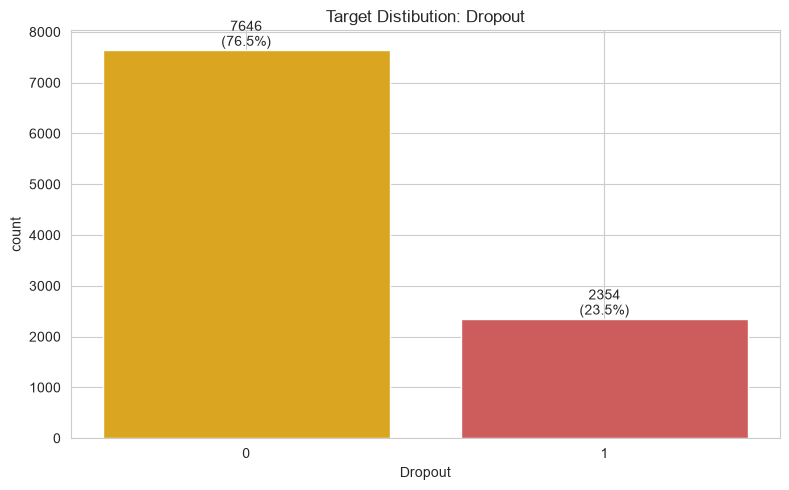

Imbalance ratio (majority/minority): 3.25
Dataset is Imbalanced


In [31]:
plot_target_distribution(df,target)

\Missing value visualization

In [32]:
def plot_missing_values(df):

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)

    if len(missing) == 0:
        print("No missing values to visualize.")
        return

    missing_pct = (missing / len(df)) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(missing.index, missing_pct.values,
                   color="goldenrod")

    for bar, pct in zip(bars, missing_pct.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f" {pct:.1f}%", va='center')

    ax.set_title("Missing Values by Column")
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()

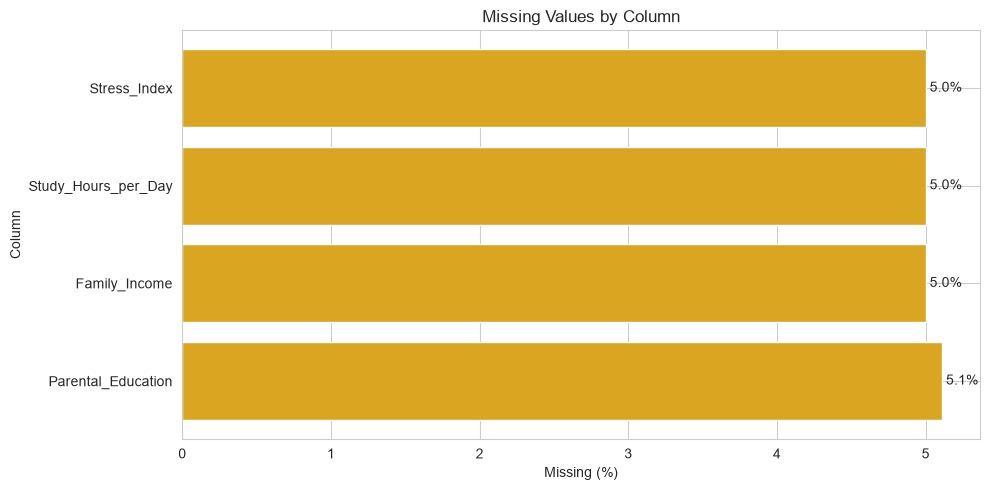

In [33]:
plot_missing_values(df_raw)

\Correlation Analysis

In [34]:
def plot_correlation(df,target=None):
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1]<2:
        print("Need atleast 2 numeric columns for correlation")
        return
    corr = numeric_df.corr()

    fig,ax = plt.subplots(figsize=(12,9))
    sns.heatmap(corr,annot=False,cmap="coolwarm",center=0,square=True,linewidths=0.5,ax=ax)
    ax.set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

    if target is not None and target in numeric_df.columns:
        target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
        print(f"Top features correlated with '{target}':")
        for col ,val in target_corr.head(10).items():
            print(f"  {col}: {val:.3f}")

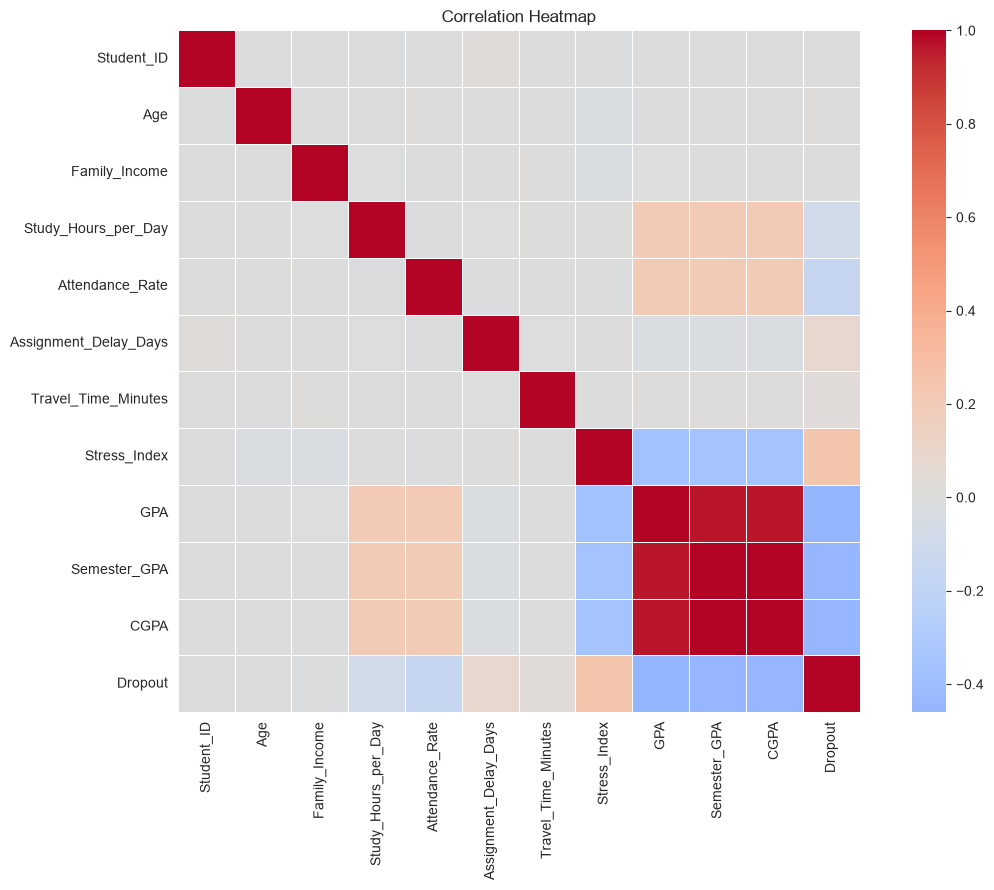

Top features correlated with 'Dropout':
  GPA: 0.460
  Semester_GPA: 0.445
  CGPA: 0.445
  Stress_Index: 0.249
  Attendance_Rate: 0.164
  Study_Hours_per_Day: 0.087
  Assignment_Delay_Days: 0.082
  Travel_Time_Minutes: 0.028
  Family_Income: 0.013
  Age: 0.007


In [35]:
plot_correlation(df,target=target)

\Numeric columns distribution

In [36]:
def plot_numeric_distributions(df, target=None, max_cols=15):
    
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)

    if len(numeric_cols) == 0:
        print("No numeric features to plot.")
        return

    numeric_cols = numeric_cols[:max_cols] 

    n = len(numeric_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols 

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  

    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col], bins=30, color='goldenrod', edgecolor='white')
        skew = df[col].skew()
        axes[i].set_title(f"{col}\n(skew={skew:.2f})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


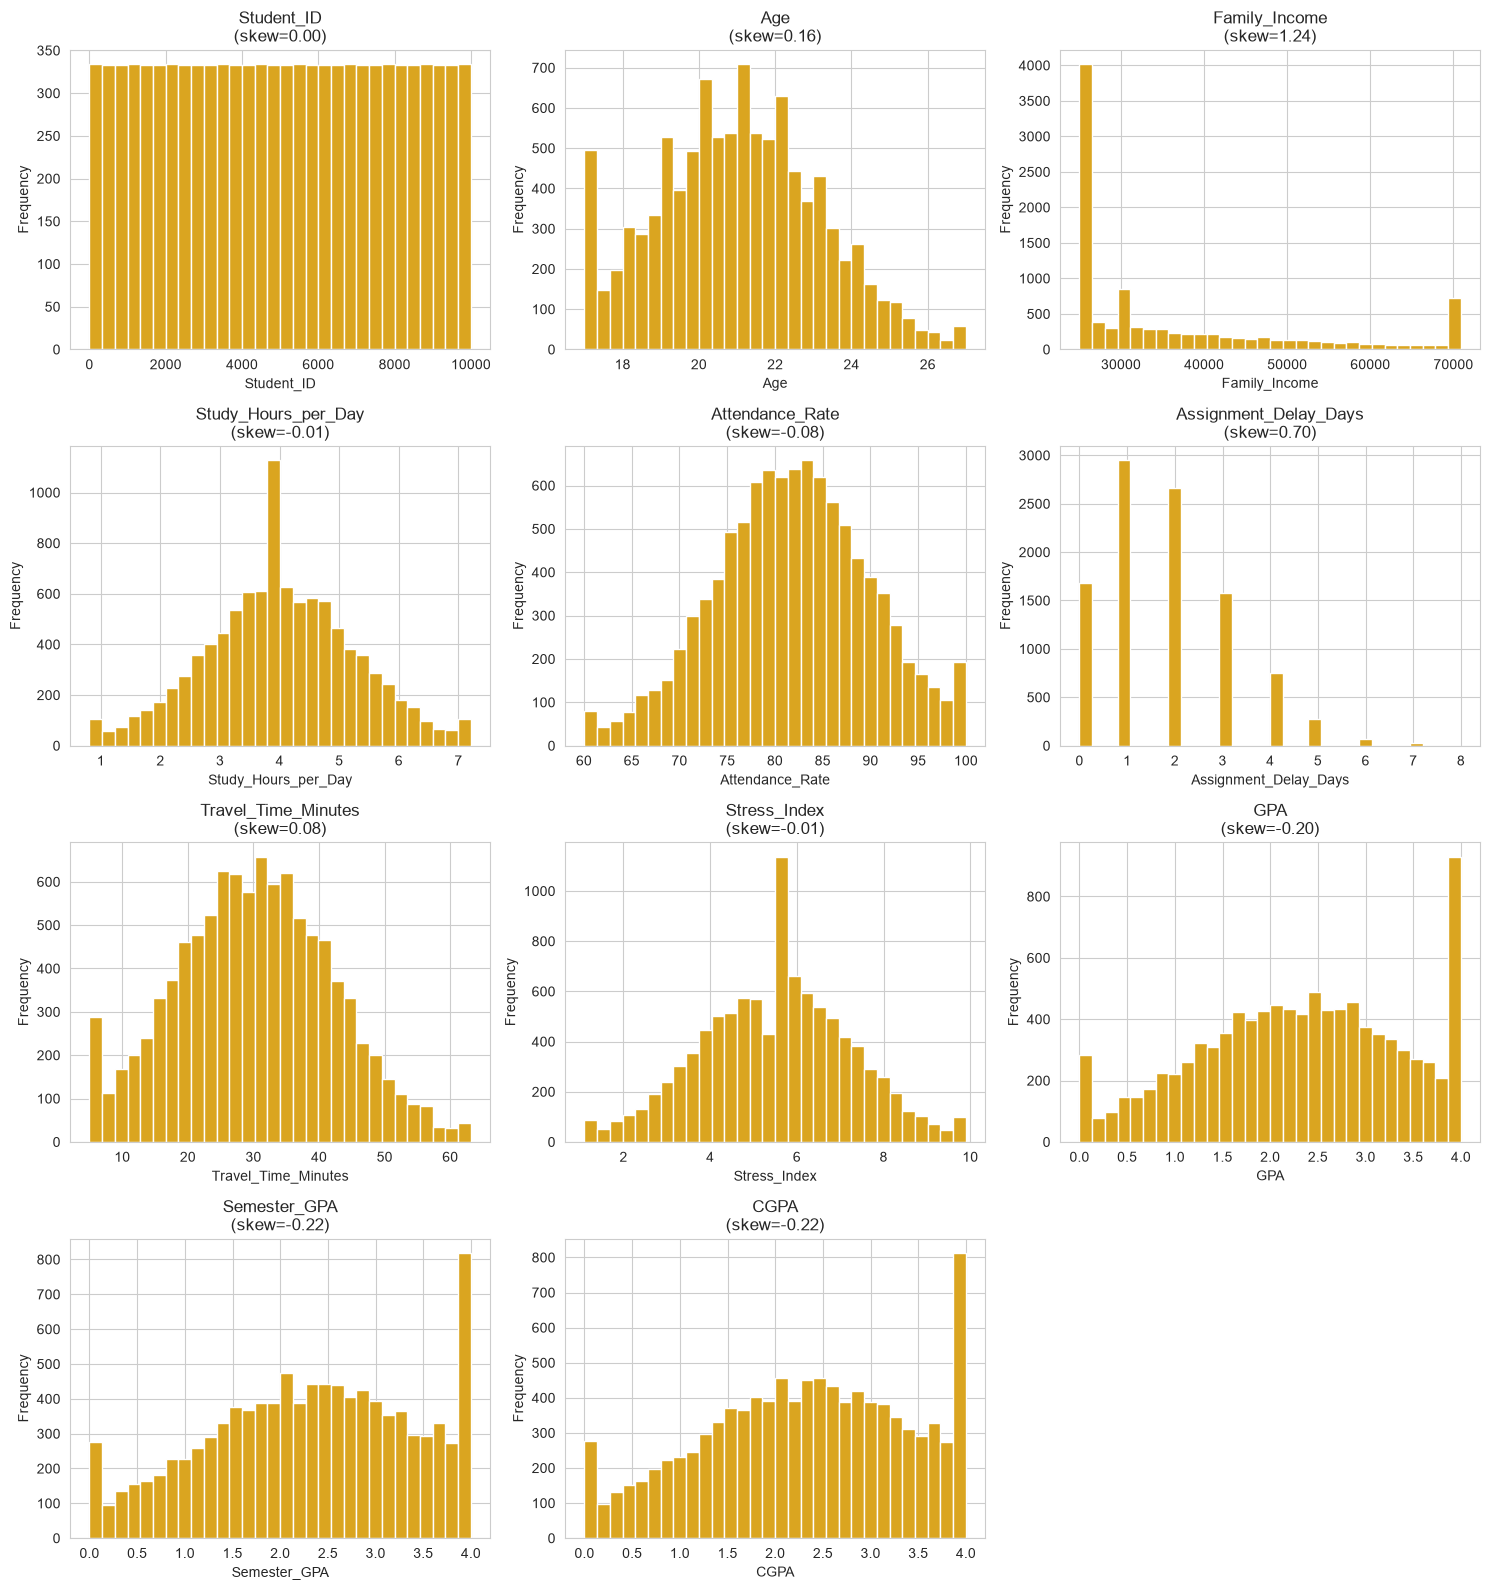

In [37]:
plot_numeric_distributions(df, target=target)

\Categorical column distribution

In [38]:
def plot_categorical_distributions(df, target=None, max_cols=10, max_categories=10):
    
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    if target in cat_cols:
        cat_cols.remove(target)
    cat_cols = [c for c in cat_cols if df[c].nunique() <= max_categories]

    if len(cat_cols) == 0:
        print("No suitable categorical features to plot.")
        return

    cat_cols = cat_cols[:max_cols]
    n = len(cat_cols)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        df[col].value_counts().plot(kind="bar", ax=axes[i], color="goldenrod")
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

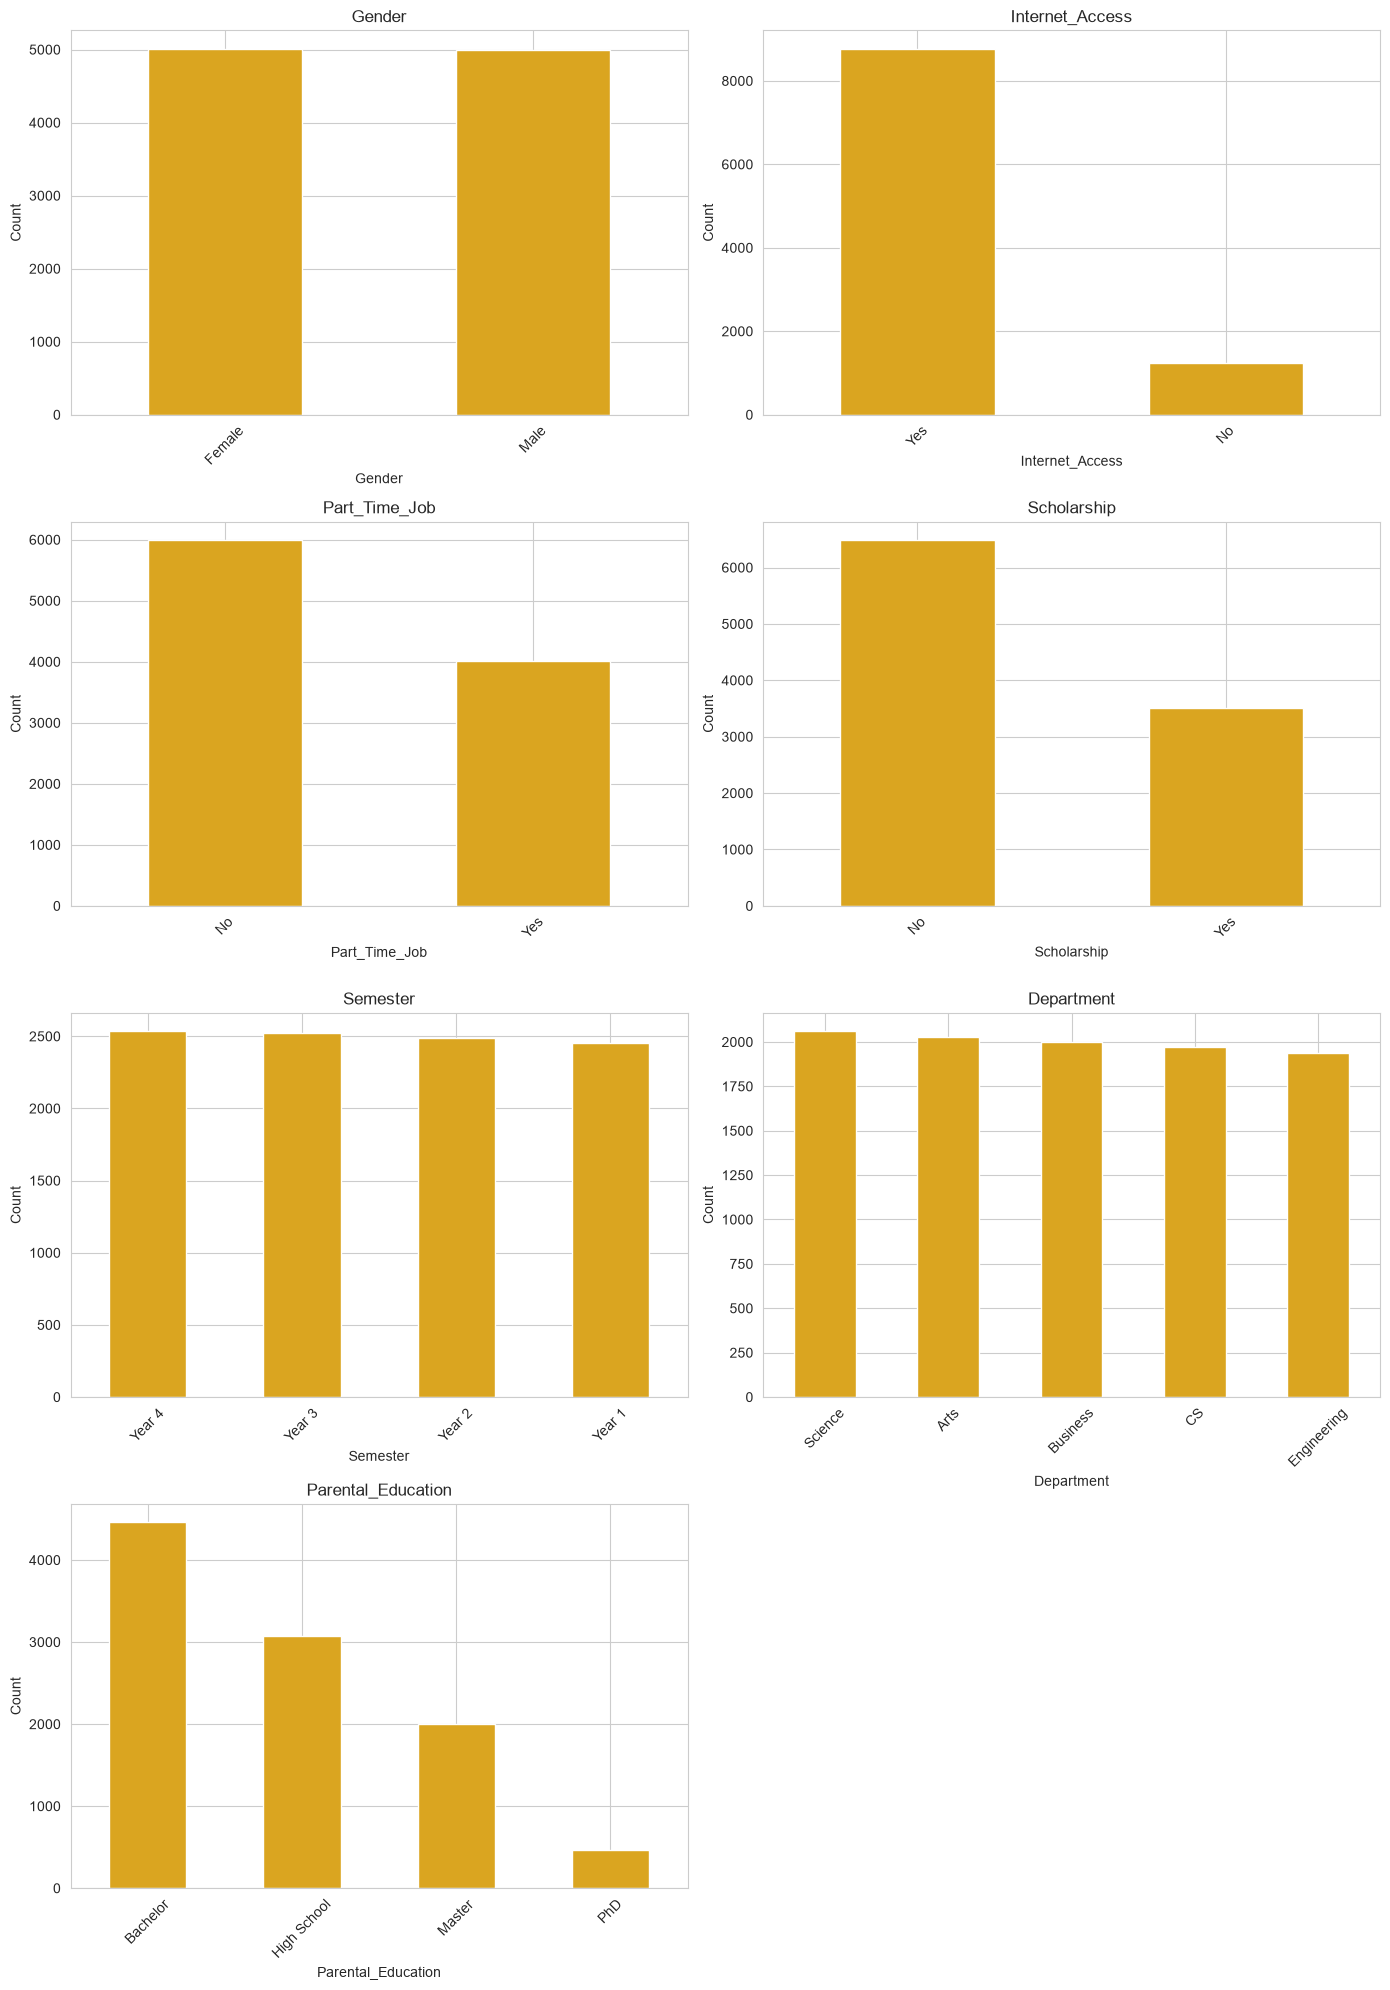

In [39]:
plot_categorical_distributions(df, target=target)

\Statistical Summary

In [40]:
def statistical_summary(df, target=None):
    
    # Numeric summary
    numeric_df = df.select_dtypes(include=np.number)
    if numeric_df.shape[1] > 0:
        print("=" * 60)
        print("NUMERIC FEATURE SUMMARY")
        print("=" * 60)
        print(numeric_df.describe().round(2).to_string())

    # Categorical summary
    cat_df = df.select_dtypes(include="object")
    if cat_df.shape[1] > 0:
        print("\n" + "=" * 60)
        print("CATEGORICAL FEATURE SUMMARY")
        print("=" * 60)
        print(cat_df.describe().to_string())

    return numeric_df.describe(), cat_df.describe()

In [41]:
num_summary, cat_summary = statistical_summary(df, target=target)

NUMERIC FEATURE SUMMARY
       Student_ID       Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index       GPA  Semester_GPA      CGPA   Dropout
count    10000.00  10000.00       10000.00             10000.00         10000.00               10000.00             10000.00      10000.00  10000.00      10000.00  10000.00  10000.00
mean      5000.50     21.02       36340.99                 4.01            81.76                   1.80                30.17          5.51      2.31          2.30      2.30      0.24
std       2886.90      2.13       14546.81                 1.25             8.13                   1.34                11.89          1.72      1.06          1.07      1.07      0.42
min          1.00     17.00       25000.00                 0.81            60.05                   0.00                 5.00          1.10      0.00          0.00      0.00      0.00
25%       2500.75     19.50       25000.00                 3.